# Returns, Volatility, and Geometric Brownian Motion

## Load data

In [76]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from typing import List, Dict
from collections import defaultdict

In [48]:
ticker = '^GSPC'
spx = yf.download(ticker, start='2025-01-01', end='2026-01-01')

spx.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2025-01-02,5868.549805,5935.089844,5829.529785,5903.259766,3621680000
2025-01-03,5942.470215,5949.339844,5888.660156,5891.069824,3667340000
2025-01-06,5975.379883,6021.040039,5960.009766,5982.810059,4940120000
2025-01-07,5909.029785,6000.680176,5890.680176,5993.259766,4517330000
2025-01-08,5918.250000,5927.890137,5874.779785,5910.660156,4441740000


## Compute simple and log returns

Simple return: $R_t = \frac{S_t - S_{t-1}}{S_{t-1}}$

Log return: $r_t = ln(\frac{S_t}{S_{t-1}})$

Relationship: $r_t = ln(R_t + 1) \approx R_t$ for small returns

Log returns are additive through time, simplifying multi-period calculations:

&nbsp;&nbsp;$r_{0,T} = ln(\frac{S_T}{S_0}) = \sum_{t=1}^T ln(\frac{S_t}{S_{t-1}}) = \sum_{t=1}^T r_t$

&nbsp;&nbsp;$R_{0,T} = \prod_{t=1}^T (1+R_t) - 1$


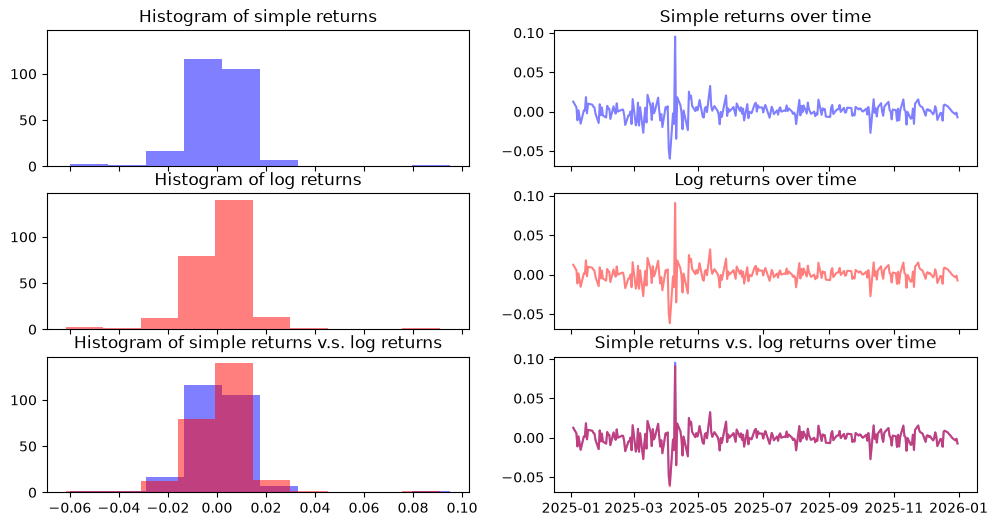

In [49]:
# simple returns
close = spx['Close'].values
lag = 1
lagged_close = close[:-lag]
close = close[lag:]
simple_returns = (close - lagged_close) / lagged_close

# log returns
log_returns = np.log(close / lagged_close)

# days
days = spx.index[lag:]


fig, ax = plt.subplots(figsize=(12,6), ncols=2, nrows=3, sharex='col', sharey='col')

# plot histograms
ax[0][0].hist(simple_returns, alpha=0.5, color='b')
ax[0][0].set_title("Histogram of simple returns")

ax[1][0].hist(log_returns, alpha=0.5, color='r')
ax[1][0].set_title("Histogram of log returns")

# plot time series
ax[0][1].plot(days, simple_returns, alpha=0.5, color='b')
ax[0][1].set_title("Simple returns over time")

ax[1][1].plot(days, log_returns, alpha=0.5, color='r')
ax[1][1].set_title("Log returns over time")

# plot simple v.s. log returns
ax[2][0].hist(simple_returns, alpha=0.5, color='b')
ax[2][0].hist(log_returns, alpha=0.5, color='r')
ax[2][0].set_title("Histogram of simple returns v.s. log returns")

ax[2][1].plot(days, simple_returns, alpha=0.5, color='b')
ax[2][1].plot(days, log_returns, alpha=0.5, color='r')
ax[2][1].set_title("Simple returns v.s. log returns over time")

plt.show();


# Simulate Geometric Brownian Motion

1. Brownian Motion (Wiener Process) $W_t$:

* Starts at origin: $W_0 = 0$
* Independent increments: $\Delta W_{t_k} = W_{t_k} - W_{t_{k-1}}$ are independent for all $t_k$
* Stationary and normal increments: $\forall s < t, \Delta W_t - W_s \sim \mathcal{N}(0, t-s)$
* Continuous paths: With probability 1, the function $t \rightarrow W_t$ is continuous

2. Ito's lemma: 

$f(S_t + d S_t) = f(S_t) + f'(S_t) d S_t + \frac{1}{2} f''(S_t) (d S_t)^2$

$=> d f(S_t) = f(S_t + d S_t) - f(S_t) = f'(S_t) d S_t + \frac{1}{2} f''(S_t) (d S_t)^2$

$=> d f(S_t) = f'(S_t) (\mu S_t dt + \sigma S_t dW_t) + \frac{1}{2} f''(S_t) (\mu S_t dt + \sigma S_t dW_t)^2$

$=> d f(S_t) = f'(S_t) (\mu S_t dt + \sigma S_t dW_t) + \frac{1}{2} f''(S_t) \sigma^2 S_t^2 dt$

$=> d f(S_t) = (f'(S_t) \mu S_t + + \frac{1}{2} f''(S_t) \sigma^2 S_t^2) dt + f'(S_t) \sigma S_t dW_t$

3. Geometric Brownian Motion (GBM): $dS_t = \mu S_t dt + \sigma S_t dW_t$

By Ito's lemma, $d ln(S_t) = (\mu - \frac{1}{2} \sigma^2) dt + \sigma dW_t$

$=> \int_0^T d ln(S_t) = \int_0^T (\mu - \frac{1}{2} \sigma^2) dt + \int_0^T \sigma dW_t$

$=> ln(S_T) - ln(S_0) = (\mu - \frac{1}{2} \sigma^2) T + \sigma (W_T - W_0)$

$=> ln(\frac{S_T}{S_0}) = (\mu - \frac{1}{2} \sigma^2) T + \sigma W_T$ where $W_0 = 0$

$=> S_T = S_0 e^{(\mu - \frac{1}{2} \sigma^2) T + \sigma W_T}$

Similarly, by integrating from $t - \Delta t$ to $t$, we have $ln(\frac{S_{t}}{S_t - \Delta t}) = (\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma d W$ where $d W = d W_t - d W_{t - \Delta t} \sim \mathcal{N}(0, \Delta t)$

$=> r_t = ln(\frac{S_t}{S_{t - \Delta t}}) = (\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \sqrt{\Delta t} Z$ where $d W = \sqrt{\Delta{t}} Z$ for some $Z \sim \mathcal{N}(0,1)$

$=> r_t \sim \mathcal{N}((\mu - \frac{1}{2} \sigma^2) \Delta t, \sigma^2 \Delta t)$ and $S_t = S_{t - \Delta t} e^{(\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \sqrt{\Delta t} Z}$

Also, $E[r_t] = (\mu - \frac{1}{2} \sigma^2) \Delta t$ and $Var(r_t) = \sigma^2 \Delta t => \mu = \frac{E[r_t]}{\Delta t} + \frac{1}{2} \sigma^2$ and $\sigma = \frac{\text{Std}(r_t)}{\sqrt{\Delta t}}$

In [50]:
def calculate_parameters(log_returns: np.ndarray):

    daily_mean_log_return = np.mean(log_returns)
    daily_log_return_std = np.std(log_returns, ddof=1)

    annualized_mean_log_return = np.mean(log_returns) * 252
    annualized_log_return_std = np.std(log_returns, ddof=1) * np.sqrt(252)

    daily_sigma = daily_log_return_std # Delta t = 1 (day)
    daily_mu = daily_mean_log_return + 1/2 * daily_sigma**2

    annualized_mu = daily_mu * 252
    annualized_sigma = daily_sigma * np.sqrt(252) 

    return annualized_mean_log_return, annualized_log_return_std, annualized_mu, annualized_sigma

annualized_mean_log_return, annualized_log_return_std, annualized_mu, annualized_sigma = calculate_parameters(log_returns)
print(f"Annualized mean log return: {annualized_mean_log_return*100:.2f}%, annualized log return volatility: {annualized_log_return_std*100:.2f}%")
print(f"Annualized mu: {annualized_mu*100:.2f}%, annualized sigma: {annualized_sigma*100:.2f}%")

Annualized mean log return: 15.58%, annualized log return volatility: 18.68%
Annualized mu: 17.33%, annualized sigma: 18.68%


Simulated prices of size 249: [np.float64(5942.47021484375), np.float64(6023.860556347026), np.float64(5937.48293339728), np.float64(5986.647945966553), np.float64(5906.376303828353), np.float64(5985.049791884679), np.float64(5880.078159847527), np.float64(5834.720733452554), np.float64(5796.794977348432), np.float64(5658.43059429045), np.float64(5719.040588751359), np.float64(5619.044286599329), np.float64(5536.680732960319), np.float64(5503.409536019761), np.float64(5555.25856362484), np.float64(5505.740632288322), np.float64(5639.61159704557), np.float64(5641.444718383943), np.float64(5625.764291946735), np.float64(5659.0418711629145), np.float64(5653.808065868635), np.float64(5587.320727037972), np.float64(5554.71440721482), np.float64(5569.0686568022375), np.float64(5676.898491214412), np.float64(5698.0492572760995), np.float64(5733.572575108228), np.float64(5588.014693195579), np.float64(5573.8793352914245), np.float64(5575.4949245344715), np.float64(5695.6861343936935), np.float

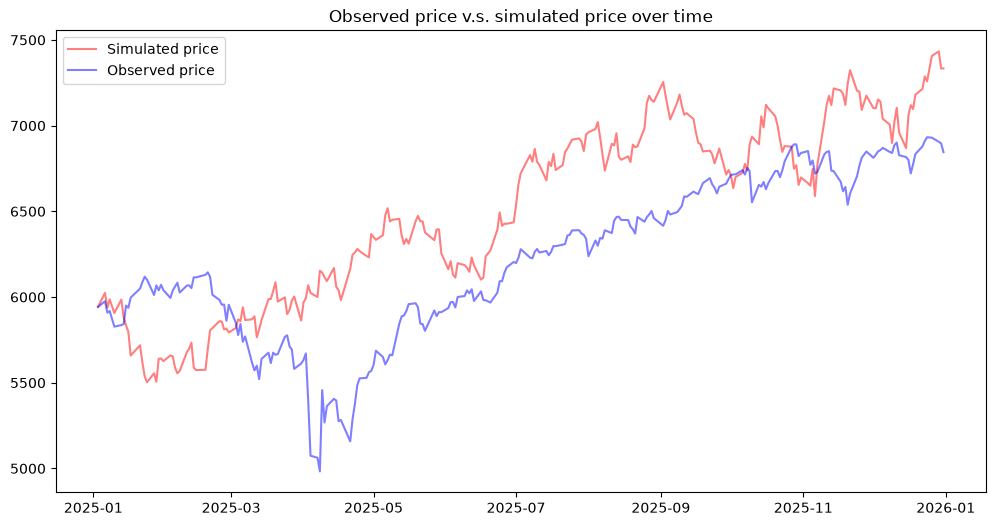

In [51]:
S0 = close[0][0]
T = len(close)
simulated_prices: List[float] = [S0]

rng = np.random.default_rng(seed=103)

daily_mu = annualized_mu / 252
daily_sigma = annualized_sigma / np.sqrt(252)

S_prev = S0;
for t in range(T-1):
    St = S_prev * np.exp((daily_mu - 1/2 * daily_sigma**2) + daily_sigma * rng.normal())
    S_prev = St
    simulated_prices.append(St)

print(f"Simulated prices of size {len(simulated_prices)}: {simulated_prices}")

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(days, simulated_prices, alpha=0.5, color='r', label='Simulated price')
ax.plot(days, close, alpha=0.5, color='b', label='Observed price')

ax.set_title("Observed price v.s. simulated price over time")
ax.legend()

plt.show()

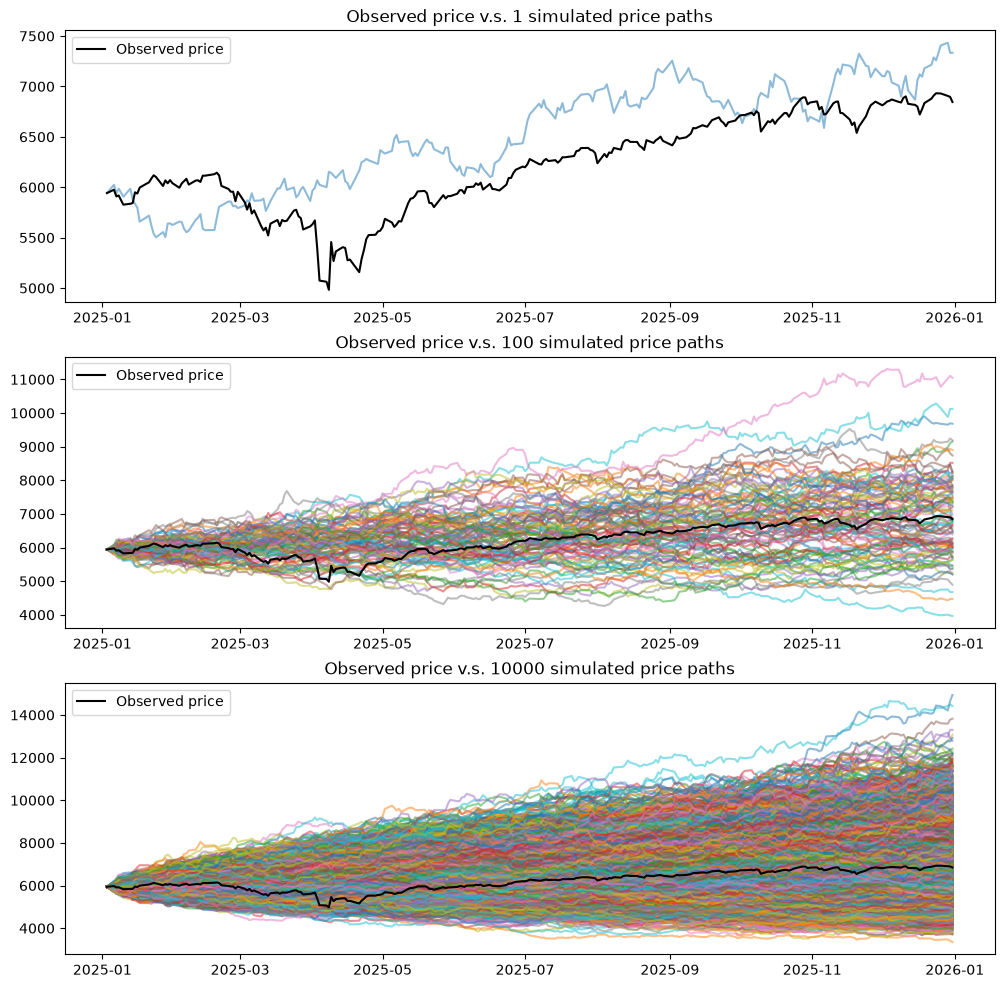

In [ ]:
simulations = [1, 100, 10000]
dt = np.ones(shape=(T-1,))
t = np.cumsum(dt)

simulated_prices: Dict[int, np.ndarray] = {}

for simulation in simulations:
    rng = np.random.default_rng(seed=103)

    dW = rng.normal(size=(simulation, T-1))
    Wt = np.cumsum(dW, axis=1)
    St = S0 * np.exp((daily_mu - 1/2 * daily_sigma**2) * t + daily_sigma * Wt)

    S0_array = np.full(shape=(simulation,), fill_value=S0)
    St = np.vstack((S0_array, St.transpose()))

    simulated_prices[simulation] = St

fig, axes = plt.subplots(figsize=(12, 12), nrows=3)
for ax, simulation in zip(axes, simulations):
    ax.plot(days, simulated_prices[simulation], alpha=0.5)
    ax.plot(days, close, label='Observed price', color='k')
    ax.set_title(f"Observed price v.s. {simulation} simulated price paths")
    ax.legend()

plt.show();

# Plot terminal-price distribution

$S_T = S_0 e^{(\mu - \frac{1}{2} \sigma^2) T + \sigma W_T}$

$W_T \sim \mathcal{N}(0,T) => S_T$ is log-normally distributed under GBM

Thus, the distribution of terminal prices under GBM is right-skewed


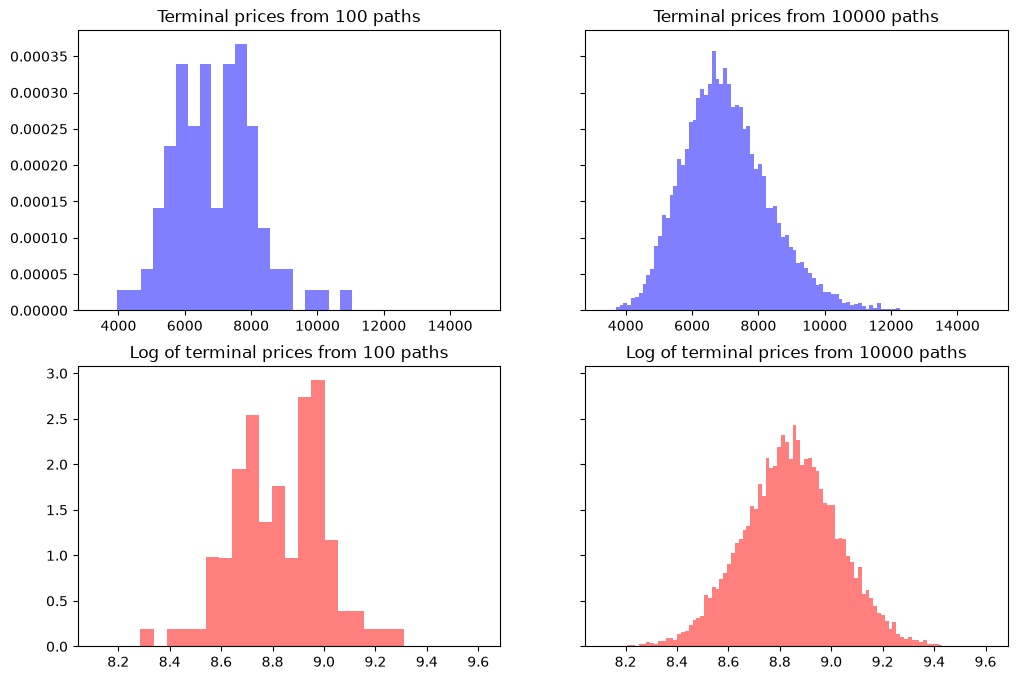

In [53]:
terminal_prices = {100: simulated_prices[100][-1,:], 10000: simulated_prices[10000][-1,:]}
log_of_terminal_prices = {100: np.log(terminal_prices[100]), 10000: np.log(terminal_prices[10000])}

fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2, sharey='row', sharex='row')

ax[0][0].hist(terminal_prices[100], color='b', alpha=0.5, density=True, bins=20)
ax[0][0].set_title("Terminal prices from 100 paths")

ax[0][1].hist(terminal_prices[10000], color='b', alpha=0.5, density=True, bins=100)
ax[0][1].set_title("Terminal prices from 10000 paths")

ax[1][0].hist(log_of_terminal_prices[100], color='r', alpha=0.5, density=True, bins=20)
ax[1][0].set_title("Log of terminal prices from 100 paths")

ax[1][1].hist(log_of_terminal_prices[10000], color='r', alpha=0.5, density=True, bins=100)
ax[1][1].set_title("Log of terminal prices from 10000 paths")

plt.show();

# Estimate parameters from simulated data

1. Chi-square distribution: 

* Chi-square RV $\chi^2(n-1) \coloneqq \sum_{i=1}^n Z_i^2$ where $Z_i \sim \mathcal{N}(0,1)$

* $E[\chi^2(n-1)] = \sum_{i=1}^n E[Z_i^2] = \sum_{i=1}^n (Var(Z_i) + (E[Z_i])^2) = \sum_{i=1}^n (1 + 0^2) = n$

* $Var(\chi^2(n-1)) = \sum_{i=1}^n Var(Z_i^2) = \sum_{i=1}^n (E[Z_i^4] - (E[Z_i^2])^2) = \sum_{i=1}^n (3 - 1^2) = 2 n$

2. 



$\mu = \frac{E[ln \frac{S_T}{S_0}]}{T} + \frac{1}{2} \sigma^2$ and $\sigma = \frac{\text{Std}(ln \frac{S_T}{S_0})}{\sqrt{T}}$



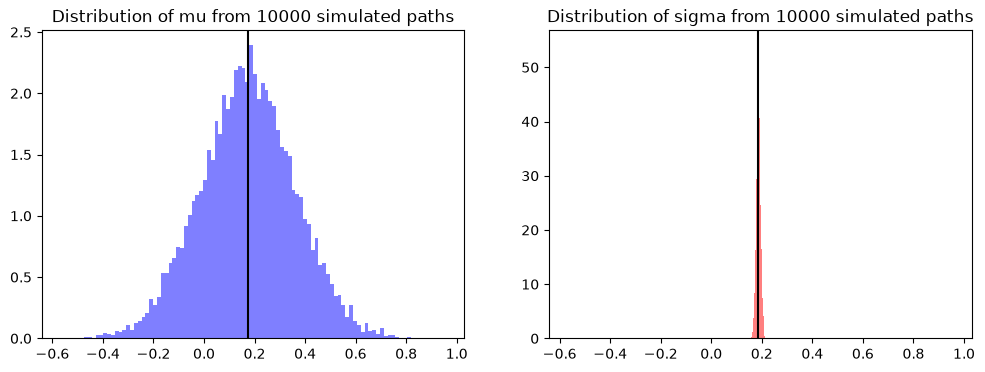

In [ ]:
# Estimate paramaters for 10000 simulated price paths
mus = []
sigmas = []

for sim in range(10000):
    prices = simulated_prices[10000][:,sim]
    lagged_prices = prices[:-lag]
    prices = prices[lag:]

    log_returns = np.log(prices / lagged_prices)

    mean, std, mu, sigma = calculate_parameters(log_returns)

    mus.append(mu)
    sigmas.append(sigma)

fig, ax = plt.subplots(figsize=(12,4), ncols=2, sharex=True)

ax[0].hist(mus, bins=100, color='b', alpha=0.5, density=True)
ax[0].set_title("Distribution of mu from 10000 simulated paths")
ax[0].axvline(annualized_mu, color='k')

ax[1].hist(sigmas, bins=100, color='r', alpha=0.5, density=True)
ax[1].set_title("Distribution of sigma from 10000 simulated paths")
ax[1].axvline(annualized_sigma, color='k')

plt.show()

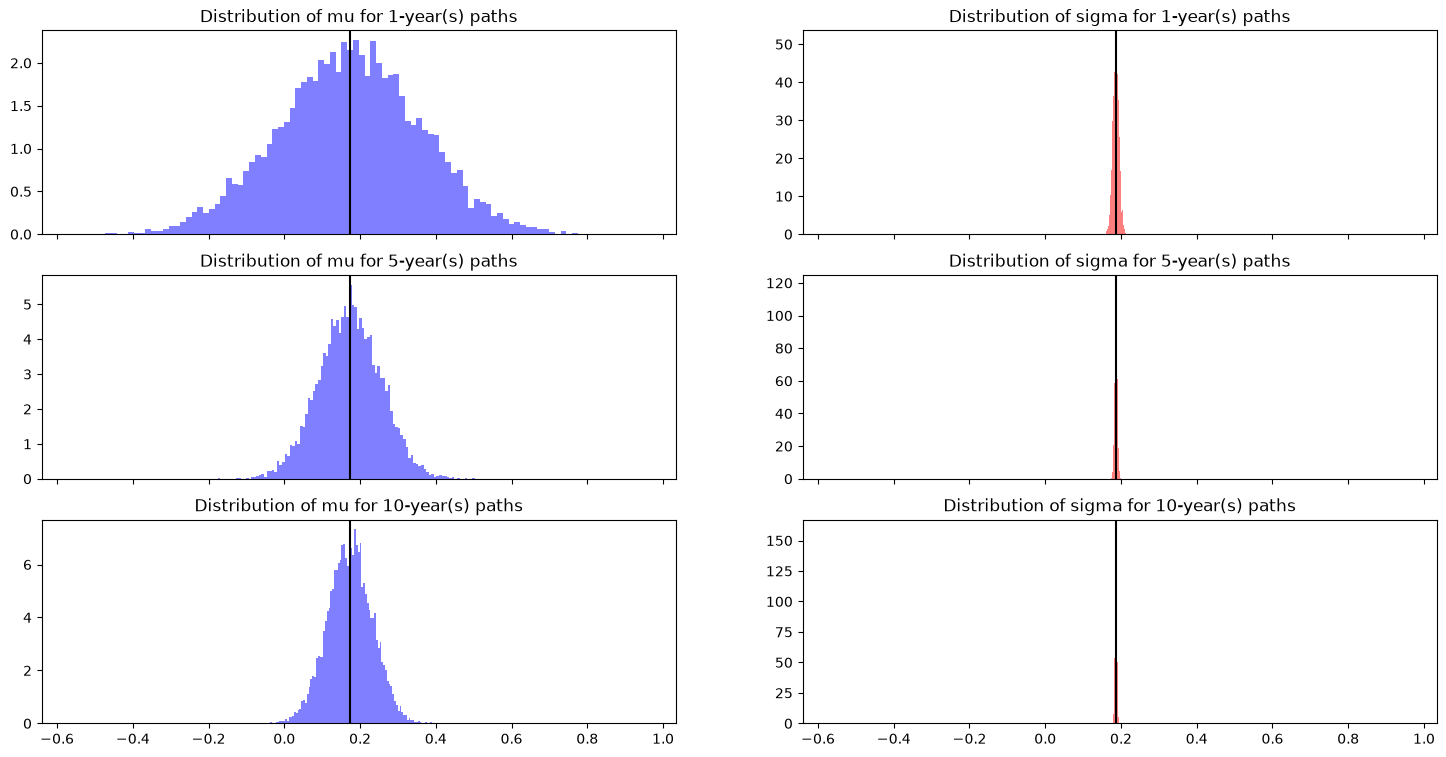

In [85]:
# Generate 10000 paths and estimate parameters for each path length (1 year, 5 years, and 10 years)
years = [1,5,10]
simulated_prices: Dict[int, np.ndarray] = {}
mus: Dict[int, List[float]] = defaultdict(list)
sigmas: Dict[int, List[float]] = defaultdict(list)

for year in years:
    T = year * 252

    dt = np.ones(shape=(T-1,))
    t = np.cumsum(dt)

    rng = np.random.default_rng(seed=103)

    dW = rng.normal(size=(10000, T-1))
    Wt = np.cumsum(dW, axis=1)
    St = S0 * np.exp((daily_mu - 1/2 * daily_sigma**2) * t + daily_sigma * Wt)

    S0_array = np.full(shape=(10000,), fill_value=S0)
    St = np.vstack((S0_array, St.transpose()))

    simulated_prices[year] = St

    for sim in range(10000):
        prices = simulated_prices[year][:,sim]
        lagged_prices = prices[:-lag]
        prices = prices[lag:]

        log_returns = np.log(prices / lagged_prices)

        mean, std, mu, sigma = calculate_parameters(log_returns)

        mus[year].append(mu)
        sigmas[year].append(sigma)

map = {
    (0,0): (1, mus[1]), (1,0): (5, mus[5]), (2,0): (10, mus[10]),
    (0,1): (1, sigmas[1]), (1,1): (5, sigmas[5]), (2,1): (10,sigmas[10])
    }

fig, ax = plt.subplots(figsize=(18,9), nrows=3, ncols=2, sharex=True)

for x, y in map.keys():
    year, estimators = map[(x,y)]

    if y == 0:
        color = 'b'
        vline = annualized_mu
        param = "mu"
    elif y == 1:
        color = 'r'
        vline = annualized_sigma
        param = "sigma"

    ax[x][y].hist(estimators, bins=100, color=color, alpha=0.5, density=True)
    ax[x][y].axvline(vline, color='k')
    ax[x][y].set_title(f"Distribution of {param} for {year}-year(s) paths")

plt.show()